In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.transform import rotation

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 50)


In [3]:
df = pd.read_csv('../data/raw/results.csv', low_memory=False)

print(f"Shape: {df.shape}")
print(f"Column count: {len(df.columns)}")
print(f"First 5 column names: {list(df.columns[:5])}")

Shape: (49191, 172)
Column count: 172
First 5 column names: ['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment']


In [4]:
target_col = 'ConvertedCompYearly'
print(f"Target column present: {target_col in df.columns}")

Target column present: True


In [5]:
salary_available = df[target_col].notna().sum()
salary_missing = df[target_col].isna().sum()

print(f'Rows with salary: {salary_available}')
print(f"Rows without salary: {salary_missing}")
print(f"Coverage : {salary_available/len(df) * 100:.1f}%")

Rows with salary: 23947
Rows without salary: 25244
Coverage : 48.7%


In [6]:
df[target_col].dropna().describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

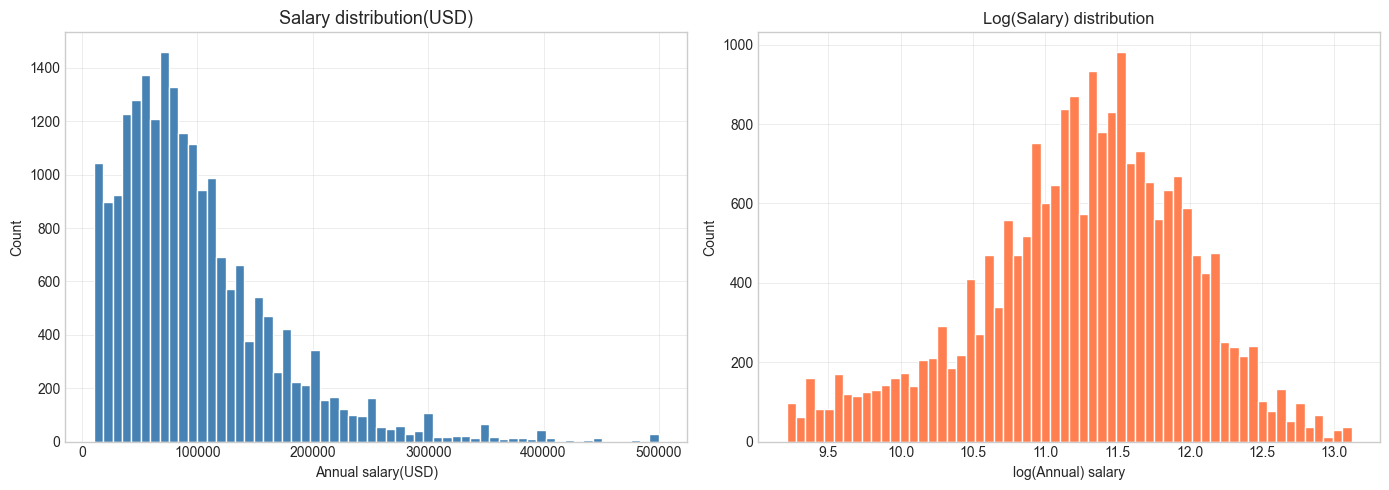

Median salary: $81,870
Mean salary: $98,572


In [7]:
salary_df = df[df[target_col].between(10000, 500000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw distribution
axes[0].hist(salary_df[target_col], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary distribution(USD)', fontsize=13)
axes[0].set_xlabel('Annual salary(USD)')
axes[0].set_ylabel('Count')

#log-scale distribution
axes[1].hist(np.log1p(salary_df[target_col]), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log(Salary) distribution')
axes[1].set_xlabel('log(Annual) salary')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/salary_distribution.png', dpi=300)
plt.show()

print(f"Median salary: ${salary_df[target_col].median():,.0f}")
print(f'Mean salary: ${salary_df[target_col].mean():,.0f}')

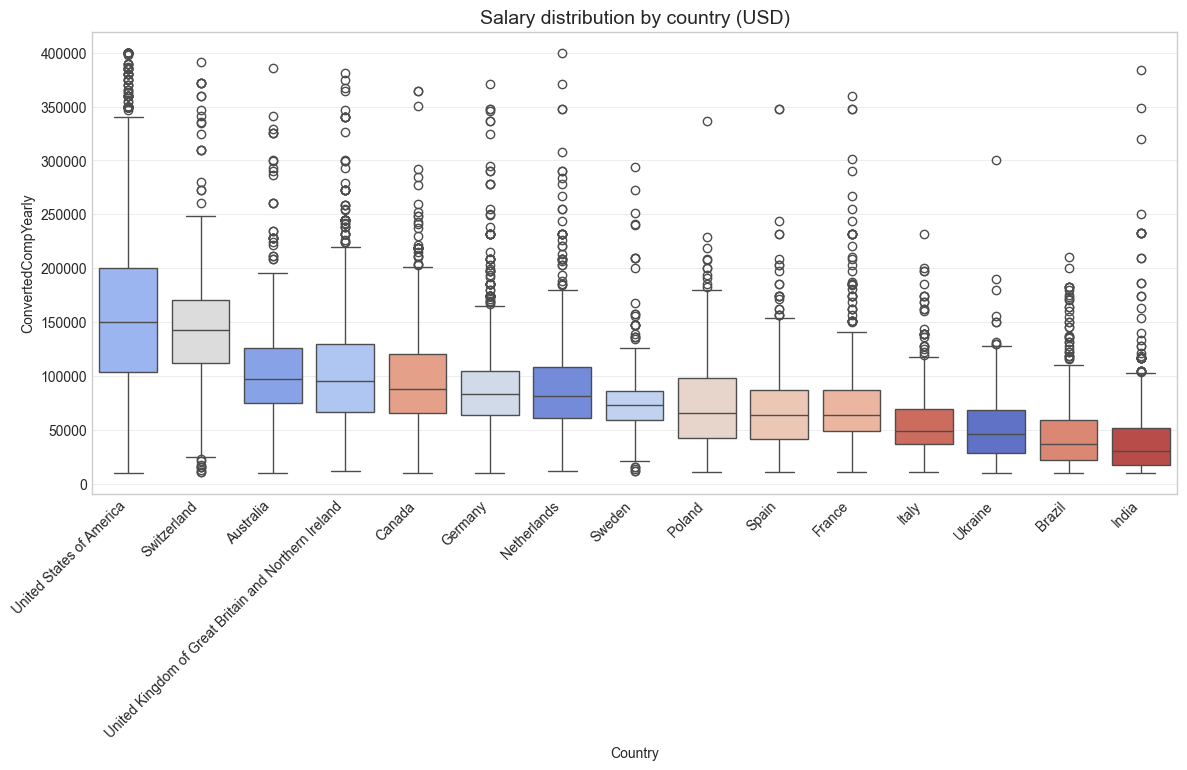

In [22]:
df_sal = df[df[target_col].between(10_000, 400_000)].copy()

top_countries = df_sal['Country'].value_counts().head(15).index
country_data = df_sal[df_sal['Country'].isin(top_countries)]

plt.figure(figsize=(14, 6))
order = country_data.groupby('Country')[target_col].median().sort_values(ascending=False).index

sns.boxplot(
    data=country_data,
    x='Country', y=target_col,
    order=order,
    palette='coolwarm',
    hue='Country',)

plt.xticks(rotation=45, ha='right')
plt.title('Salary distribution by country (USD)', fontsize=14)
plt.show()

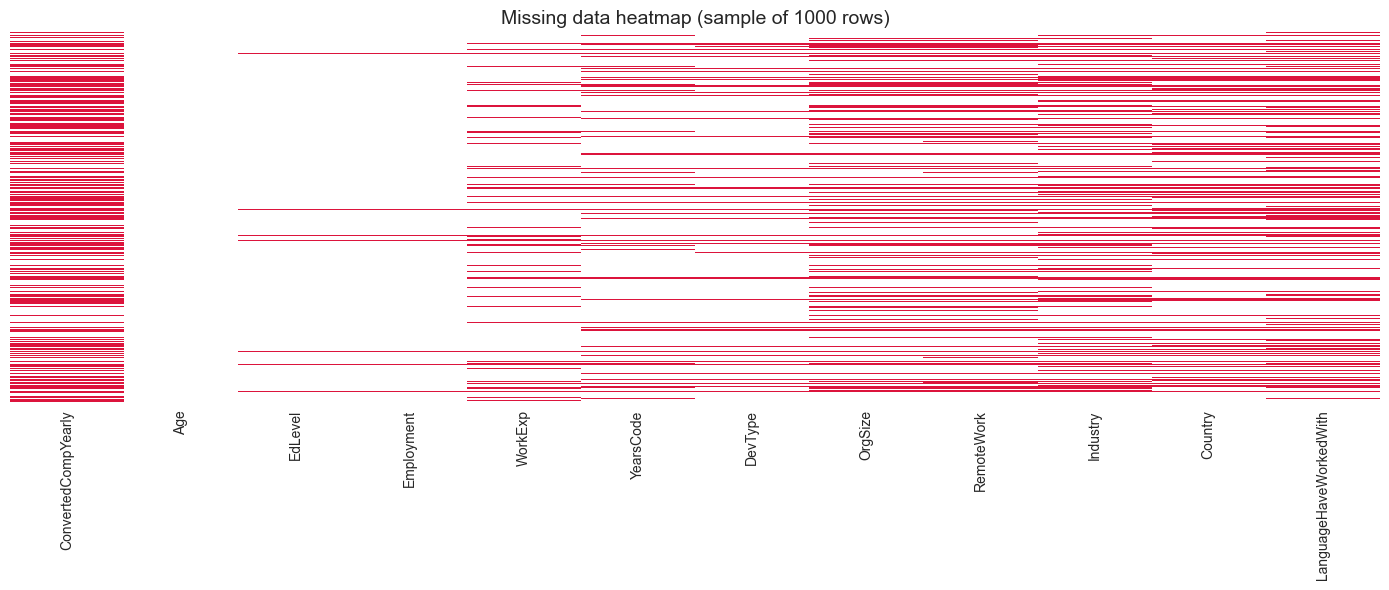

In [29]:
selected_cols = [target_col, 'Age', 'EdLevel', 'Employment', 'WorkExp', 'YearsCode', 'DevType', 'OrgSize', 'RemoteWork', 'Industry', 'Country', 'LanguageHaveWorkedWith']
available_cols = [c for c in selected_cols if c in df.columns]
missing_df = df[available_cols].isna()
plt.figure(figsize=(14, 6))
sns.heatmap(missing_df.sample(min(1000, len(df)), random_state = 42), cbar=False, yticklabels=False, xticklabels=True, cmap=['white', 'crimson'])
plt.title('Missing data heatmap (sample of 1000 rows)', fontsize=14)
plt.tight_layout()
plt.show()


Feature selection and cleaning:
1. Feature decisions - which features do want to use and why. is cleaning needed?
2. Create a preprocessing file, ie src/preprocessing.py, have several cleaning functions, then after cleaning the data,
3. Pipeline and model training